# Análisis de Datos con Python II

In [1]:
import pandas as pd

In [2]:
# Importar base de datos de exoplanetas
data_url = "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI?table=cumulative&select=kepid,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr&format=csv"
df_0 = pd.read_csv(data_url)

In [3]:
# Eliminación de los renglones que contienen valores NaN
df_1=df_0.dropna().reset_index(drop=True)
df_1

,kepid,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr
0,10797460,K00752.01,CONFIRMED,9.488036,0.146,2.95750,615.8,2.26,793.0,93.59,35.8
1,10797460,K00752.02,CONFIRMED,54.418383,0.586,4.50700,874.8,2.83,443.0,9.11,25.8
2,10811496,K00753.01,CANDIDATE,19.899140,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3
3,10848459,K00754.01,FALSE POSITIVE,1.736952,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6
4,10854555,K00755.01,CONFIRMED,2.525592,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9
...,...,...,...,...,...,...,...,...,...,...,...
9196,10090151,K07985.01,FALSE POSITIVE,0.527699,1.252,3.22210,1579.2,29.35,2088.0,4500.53,453.3
9197,10128825,K07986.01,CANDIDATE,1.739849,0.043,3.11400,48.5,0.72,1608.0,1585.81,10.6
9198,10147276,K07987.01,FALSE POSITIVE,0.681402,0.147,0.86500,103.6,1.07,2218.0,5713.41,12.3
9199,10155286,K07988.01,CANDIDATE,333.486169,0.214,3.19900,639.1,19.30,557.0,22.68,14.0


**Filtro de Datos**

Dada la disparidad tan grande entre la mediana y la media, en esta base de datos hay muchos datos atípicos en las colas de la distribución, que pueden descartarse en un primer análisis de los datos.

In [15]:
def filtro(base,col,factor):
  '''Función que elimina datos de las colas de la columna indicada de una base de datos determinando el indice intercuartílico
y seleccionando elementos que están por encima del tercer cuartil a una distancia indice_intercuartil*factor y elementos que están por abajo del segundo cuartil a la misma distancia'''
  indice_intercuartil=base[col].quantile(0.75)-base[col].quantile(0.25)
  filtro_inferior=base[col]>base[col].quantile(0.25)-(indice_intercuartil*factor)
  filtro_superior=base[col]<base[col].quantile(0.75)+(indice_intercuartil*factor)
  return base[filtro_inferior & filtro_superior]

In [20]:
# Dataframe filtrado con respecto al radio planetario
df_2=filtro(df_1,'koi_prad',2)

**Visualización de Datos**

In [4]:
import seaborn as sns

[Text(0.5, 0, 'Radio (Radios terrestres)')]

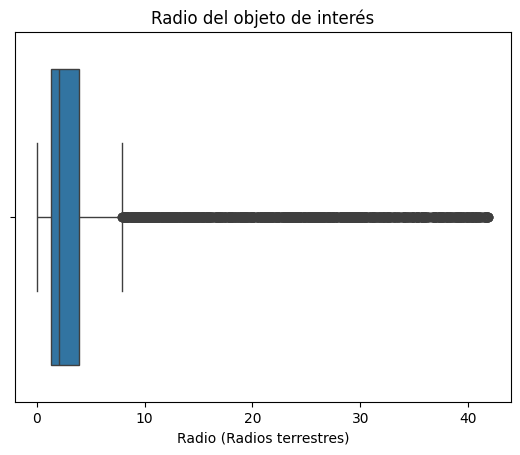

In [43]:
eje_0=sns.boxplot(x=df_2.koi_prad)
eje_0.set_title('Radio del objeto de interés')
eje_0.set(xlabel='Radio (Radios terrestres)')

In [29]:
(df_2.koi_prad).size

7967

**Tabla de Frecuencias**

In [26]:
import numpy as np

In [30]:
#Número de bins: Regla de Sturges n=1+log_2(Total)
bins=int(1+np.log2((df_2.koi_prad).size))
bins

13

In [32]:
# Determinar a cual bin corresponde cada elemento de nuestra columna
frecuencia_radio=pd.cut(df_2.koi_prad,bins)
frecuencia_radio

,koi_prad
0,"(0.0382, 3.292]"
1,"(0.0382, 3.292]"
2,"(12.929, 16.142]"
3,"(32.203, 35.415]"
4,"(0.0382, 3.292]"
...,...
9196,"(28.991, 32.203]"
9197,"(0.0382, 3.292]"
9198,"(0.0382, 3.292]"
9199,"(16.142, 19.354]"


In [33]:
# Tabla de frecuencia


In [36]:
(df_2.koi_prad).groupby(frecuencia_radio).count()

/tmp/ipython-input-4064101924.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df_2.koi_prad).groupby(frecuencia_radio).count()


,koi_prad
koi_prad,
"(0.0382, 3.292]",5691
"(3.292, 6.505]",693
"(6.505, 9.717]",237
"(9.717, 12.929]",181
"(12.929, 16.142]",148
"(16.142, 19.354]",122
"(19.354, 22.566]",135
"(22.566, 25.778]",153
"(25.778, 28.991]",141


**Histograma**

[Text(0.5, 0, 'Radio (Radios terrestres)'), Text(0, 0.5, 'Total')]

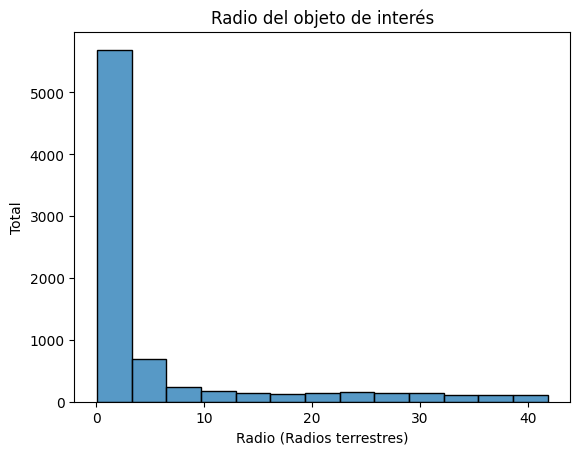

In [41]:
eje_1=sns.histplot(df_2.koi_prad,bins=bins)
eje_1.set_title('Radio del objeto de interés')
eje_1.set(xlabel='Radio (Radios terrestres)',ylabel='Total')

**Densidad de probabilidad**

[Text(0.5, 0, 'Radio (Radios terrestres)'), Text(0, 0.5, 'Densidad')]

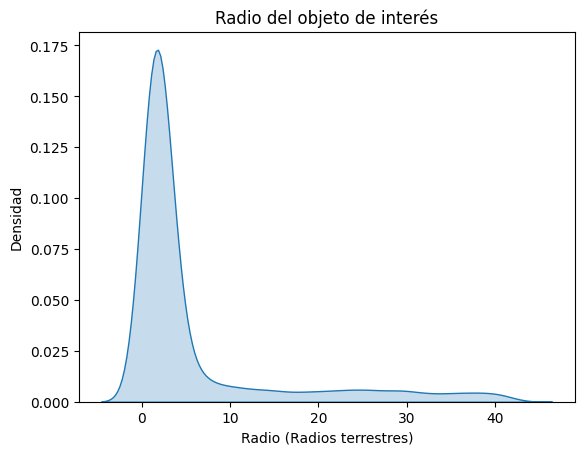

In [44]:
eje_2=sns.kdeplot(df_2.koi_prad,fill=True)
eje_2.set_title('Radio del objeto de interés')
eje_2.set(xlabel='Radio (Radios terrestres)',ylabel='Densidad')